In [1]:
!pip install --upgrade pip

Looking in indexes: https://mirrors.cloud.aliyuncs.com/pypi/simple
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 26.1 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: pip
    Found existing installation: pip 23.3.2
    Uninstalling pip-23.3.2:
      Successfully uninstalled pip-23.3.2


In [2]:
!pip install fvcore iopath matplotlib ninja

Looking in indexes: https://mirrors.cloud.aliyuncs.com/pypi/simple
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for fvcore: filename=fvcore-0.1.5.post20221221-py3-none-any.whl size=61443 sha256=9f40ea46160d9a8dd2eaef02e8dd2980b3c67d90fa634cf8a19092cb96a5ab88
  Stored in directory: /root/.cache/pip/wheels/f6/44/9b/cd6191e137e248451f5d90caffab706f75e3b4b5bde8b9c403
  Created wheel for iopath: filename=iopath-0.1.10-py3-none-any.whl size=31596 sha256=30437b40bcc3cf769b9ed016655b12313ce44dcf4ab073598dfaf8011b7ab6aa
  Stored in directory: /root/.cache/pip/wheels/f2/54/02/259baffec44ff4bd647d79f11e1aade7e428a66dd585494aad
Successfully built fvcore iopath
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [fvcore]


In [3]:
!pip install "git+https://gitee.com/hongwenzhang/pytorch3d.git" --no-build-isolation

Looking in indexes: https://mirrors.cloud.aliyuncs.com/pypi/simple
  Cloning https://gitee.com/hongwenzhang/pytorch3d.git to /tmp/pip-req-build-giee4t60
  Running command git clone --filter=blob:none --quiet https://gitee.com/hongwenzhang/pytorch3d.git /tmp/pip-req-build-giee4t60
  Resolved https://gitee.com/hongwenzhang/pytorch3d.git to commit b6a77ad7aaf41ed90fca80ce6a2bac3c462a7881
  Preparing metadata (pyproject.toml) ... done
  Created wheel for pytorch3d: filename=pytorch3d-0.7.9-cp311-cp311-linux_x86_64.whl size=64484411 sha256=cc7f360789bd48108b74dec2a6a297c4d4f881a0f98ca358f6dd92074b37e28b
  Stored in directory: /tmp/pip-ephem-wheel-cache-97j_kbs9/wheels/2d/8b/12/6e318153711ff74bb8bc1b6ef9e1f7fb0efd88402eace988f3
Successfully built pytorch3d


Epoch 299/300
Total Loss      : 0.004741
Silhouette Loss : 0.000925
Laplacian Loss  : 0.005531
Edge Loss       : 0.004121
Normal Loss     : 0.022577
[SAVE] Mesh 已保存: results/meshes/mesh_epoch_299.obj


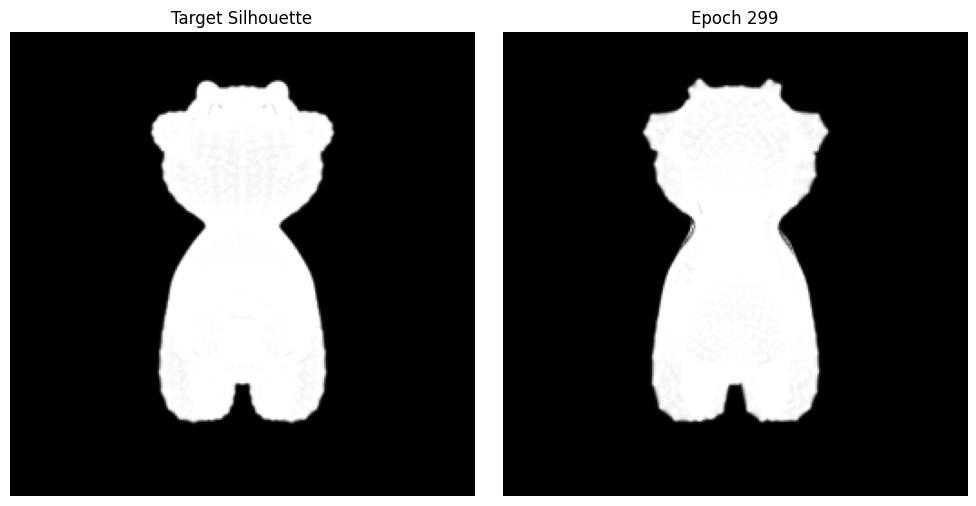

100%|██████████| 300/300 [00:36<00:00,  8.21it/s]




[INFO] 优化完成！
[INFO] 最终模型保存至: results/final_cow.obj


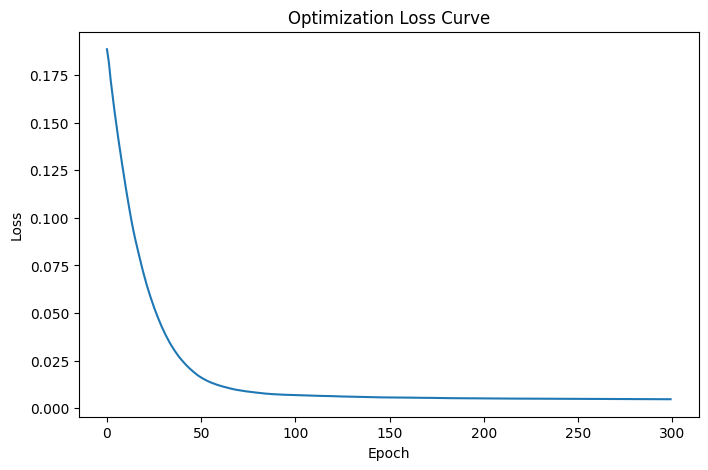

[INFO] Loss 曲线已保存至: results/loss_curve.png


In [4]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm
from IPython.display import clear_output

import pytorch3d
from pytorch3d.io import load_obj, save_obj
from pytorch3d.structures import Meshes
from pytorch3d.utils import ico_sphere

from pytorch3d.loss import (
    mesh_edge_loss,
    mesh_laplacian_smoothing,
    mesh_normal_consistency
)

from pytorch3d.renderer import (
    look_at_view_transform,
    FoVPerspectiveCameras,
    RasterizationSettings,
    MeshRasterizer,
    SoftSilhouetteShader,
    BlendParams
)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

print("=" * 50)
print(f"当前运行设备: {device}")
print(f"PyTorch3D 版本: {pytorch3d.__version__}")
print("=" * 50)


output_dir = "results"
mesh_dir = os.path.join(output_dir, "meshes")
image_dir = os.path.join(output_dir, "images")

os.makedirs(mesh_dir, exist_ok=True)
os.makedirs(image_dir, exist_ok=True)

obj_path = "cow.obj"

if not os.path.exists(obj_path):
    raise FileNotFoundError(
        "未找到 cow.obj，请确保其与代码在同一目录下！"
    )

print("[INFO] 正在加载目标奶牛模型...")

verts, faces, _ = load_obj(obj_path)

verts = verts.to(device)
faces_idx = faces.verts_idx.to(device)

verts = verts - verts.mean(0)

scale = torch.max(torch.abs(verts))
verts = verts / scale

target_mesh = Meshes(
    verts=[verts],
    faces=[faces_idx]
)

print("[INFO] 奶牛模型加载完成！")

num_views = 20

elev = torch.linspace(-20, 20, num_views)
azim = torch.linspace(-180, 180, num_views)

R, T = look_at_view_transform(
    dist=2.7,
    elev=elev,
    azim=azim
)

cameras = FoVPerspectiveCameras(
    device=device,
    R=R,
    T=T
)

sigma = 1e-4

raster_settings = RasterizationSettings(
    image_size=256,
    blur_radius=np.log(1. / 1e-4 - 1.) * sigma,
    faces_per_pixel=50
)

blend_params = BlendParams(
    sigma=sigma,
    gamma=1e-4
)

rasterizer = MeshRasterizer(
    cameras=cameras,
    raster_settings=raster_settings
)

shader = SoftSilhouetteShader(
    blend_params=blend_params
)

print("[INFO] 正在渲染目标剪影图...")

with torch.no_grad():

    target_silhouette = shader(
        rasterizer(target_mesh.extend(num_views)),
        target_mesh.extend(num_views)
    )[..., 3]

print("[INFO] 目标剪影生成完成！")


print("[INFO] 初始化球体模型...")

src_mesh = ico_sphere(4, device)

deform_verts = torch.zeros_like(
    src_mesh.verts_packed(),
    requires_grad=True
)


optimizer = torch.optim.Adam(
    [deform_verts],
    lr=0.01
)


w_silhouette = 1.0
w_laplacian = 0.5
w_edge = 0.2
w_normal = 0.01

epochs = 300

loss_history = []

print("[INFO] 开始执行可微优化...")

for epoch in tqdm(range(epochs)):

    optimizer.zero_grad()


    new_mesh = src_mesh.offset_verts(deform_verts)

    pred_silhouette = shader(
        rasterizer(new_mesh.extend(num_views)),
        new_mesh.extend(num_views)
    )[..., 3]


    loss_silhouette = (
        (pred_silhouette - target_silhouette) ** 2
    ).mean()

    loss_laplacian = mesh_laplacian_smoothing(
        new_mesh,
        method="uniform"
    )

    loss_edge = mesh_edge_loss(new_mesh)

    loss_normal = mesh_normal_consistency(new_mesh)

    loss = (
        w_silhouette * loss_silhouette
        + w_laplacian * loss_laplacian
        + w_edge * loss_edge
        + w_normal * loss_normal
    )

    loss.backward()

    optimizer.step()

    loss_history.append(loss.item())

    if epoch % 20 == 0 or epoch == epochs - 1:

        clear_output(wait=True)

        print("=" * 60)
        print(f"Epoch {epoch}/{epochs}")
        print(f"Total Loss      : {loss.item():.6f}")
        print(f"Silhouette Loss : {loss_silhouette.item():.6f}")
        print(f"Laplacian Loss  : {loss_laplacian.item():.6f}")
        print(f"Edge Loss       : {loss_edge.item():.6f}")
        print(f"Normal Loss     : {loss_normal.item():.6f}")
        print("=" * 60)

        current_verts = new_mesh.verts_list()[0]
        current_faces = new_mesh.faces_list()[0]

        mesh_save_path = os.path.join(
            mesh_dir,
            f"mesh_epoch_{epoch:03d}.obj"
        )

        save_obj(
            mesh_save_path,
            current_verts,
            current_faces
        )

        print(f"[SAVE] Mesh 已保存: {mesh_save_path}")


        fig, ax = plt.subplots(1, 2, figsize=(10, 5))

        ax[0].imshow(
            target_silhouette[0].cpu().numpy(),
            cmap="gray"
        )

        ax[0].set_title("Target Silhouette")
        ax[0].axis("off")

        ax[1].imshow(
            pred_silhouette[0].detach().cpu().numpy(),
            cmap="gray"
        )

        ax[1].set_title(f"Epoch {epoch}")
        ax[1].axis("off")

        plt.tight_layout()

        image_save_path = os.path.join(
            image_dir,
            f"epoch_{epoch:03d}.png"
        )

        plt.savefig(image_save_path)

        plt.show()

final_mesh = src_mesh.offset_verts(deform_verts)

final_verts = final_mesh.verts_list()[0]
final_faces = final_mesh.faces_list()[0]

final_obj_path = os.path.join(
    output_dir,
    "final_cow.obj"
)

save_obj(
    final_obj_path,
    final_verts,
    final_faces
)

print("\n")
print("=" * 60)
print("[INFO] 优化完成！")
print(f"[INFO] 最终模型保存至: {final_obj_path}")
print("=" * 60)

plt.figure(figsize=(8, 5))

plt.plot(loss_history)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Optimization Loss Curve")

loss_curve_path = os.path.join(
    output_dir,
    "loss_curve.png"
)

plt.savefig(loss_curve_path)

plt.show()

print(f"[INFO] Loss 曲线已保存至: {loss_curve_path}")